# Bayesian Optimization

# Linear Regression

In [110]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(-5, 5, N)
y =  - 0.5 * x + 0.2 * x**2 + 3 * np.cos(x)
data = y + np.random.normal(scale=2, size=N)

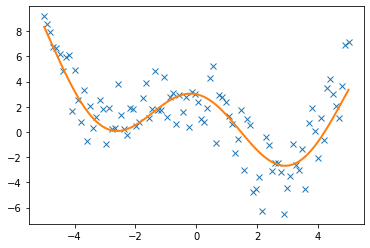

In [112]:
plt.plot(x, data, "x")
plt.plot(x, y, linewidth=2)
plt.show()

In [136]:
import pymc3 as pm

with pm.Model() as model:
    beta = pm.Normal('beta', mu=0, sigma=3, shape=3)
    comb = beta[0] * x + beta[1] * x ** 2 + beta[2] * np.cos(x)
    sigma = pm.HalfNormal("sigma", sigma=10)
    yhat = pm.Normal('yhat', mu=comb, sigma=sigma, observed=data)

    trace = pm.sample(5000, chains=2)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_67119/2009850971.py:9: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [sigma, beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 6 seconds.


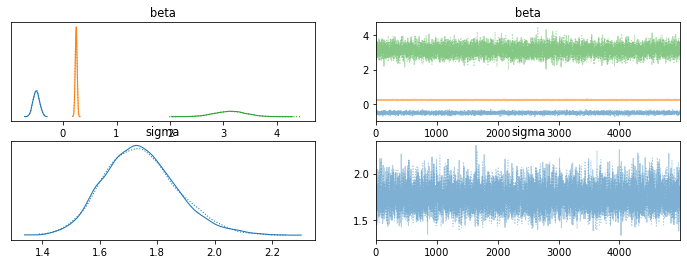

In [137]:
import arviz as az

with model:
    az.plot_trace(trace)

In [124]:
data2 = np.array(list(zip(x, data)))
np.random.shuffle(data2)

In [128]:
x2, y2 = data2[:10,0], data2[:10,1]

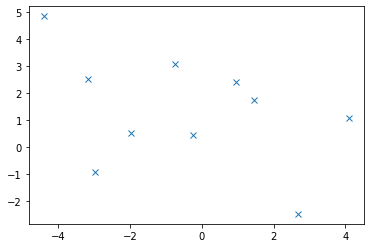

In [131]:
plt.plot(x2, y2, "x")
plt.show()

In [138]:
with pm.Model() as model2:
    beta = pm.Normal('beta', mu=0, sigma=3, shape=3)
    comb = beta[0] * x2 + beta[1] * x2 ** 2 + beta[2] * np.cos(x2)
    sigma = pm.HalfNormal("sigma", sigma=10)
    yhat = pm.Normal('yhat', mu=comb, sigma=sigma, observed=y2)

    trace2 = pm.sample(5000, chains=2)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_67119/4004690666.py:7: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace2 = pm.sample(5000, chains=2)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [sigma, beta]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 7 seconds.


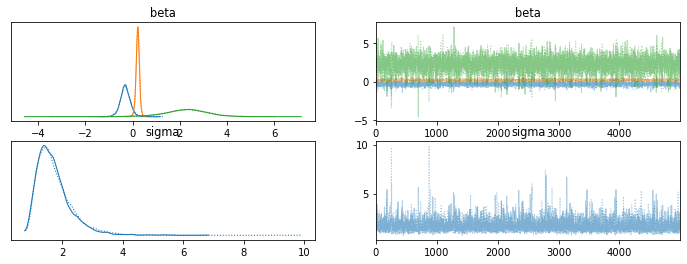

In [139]:
import arviz as az

with model2:
    az.plot_trace(trace2)

In [208]:
num_sample = 20
with model2:
    pred_func = pm.sample_posterior_predictive(trace2, var_names=["beta", "sigma"], samples=num_sample)

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


In [209]:
funcs = np.array(pred_func['beta']) @ np.array([x, x**2, np.cos(x)])

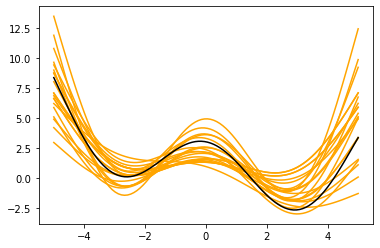

In [210]:
for i in range(num_sample):
    plt.plot(x, funcs[i,:], color='orange')
plt.plot(x, y, color='black')
plt.show()

# Multivariate Gaussian

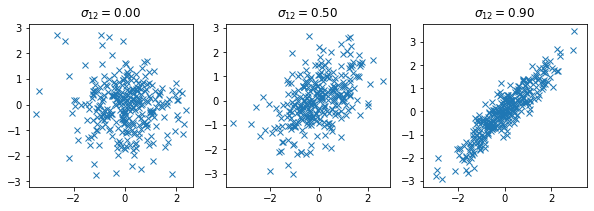

In [285]:
import numpy as np
import matplotlib.pyplot as plt

mean = [0, 0]

cov12s = [0, 0.5, 0.9]

fig, ax = plt.subplots(1, 3, figsize=(10,3))

for i, cov12 in enumerate(cov12s):
    cov = [[1, cov12],
           [cov12, 1]]

    x, y = np.random.multivariate_normal(mean, cov, 300).T
    ax[i].plot(x, y, 'x')
    ax[i].set(xlim=(-3, 3), ylim=(-3, 3))
    ax[i].set_title(r"$\sigma_{12}={%.2f}$" % cov12)
    ax[i].axis('equal')
plt.show()

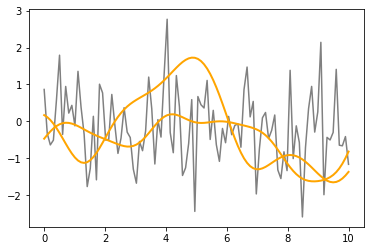

In [342]:
import numpy as np
from scipy import stats

x = np.linspace(0, 10, 100)

f_norm = stats.norm.rvs(loc=0, scale=1, size=100) # mean 0, stdev 1

plt.plot(x, f_norm, color='gray')

def exp_quad_kernel(x, knots, length=1):
    """exponentiated quadratic kernel"""
    return np.array([np.exp(-(x-k)**2 / (2*length**2)) for k in knots])

cov = exp_quad_kernel(x, x)
f_mvn = stats.multivariate_normal.rvs(cov=cov, size=2).T
plt.plot(x, f_mvn, color="orange", linewidth=2)



fig.text(0.51, -0.03, 'x', fontsize=16)
fig.text(-0.03, 0.5, 'f(x)', fontsize=16)
plt.show()

# Gaussian Process

Text(0, 0.5, 'f(x)')

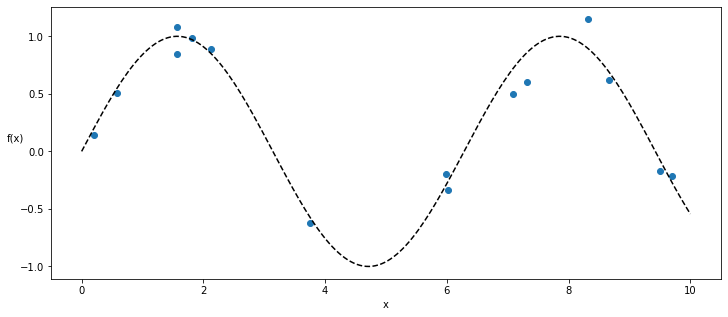

In [294]:
import pymc3 as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.uniform(0, 10, size=15)
y = np.random.normal(np.sin(x), 0.1)

_, ax = plt.subplots(figsize=(12,5))
ax.plot(x, y, 'o')

true_x = np.linspace(0, 10, 200)
ax.plot(true_x, np.sin(true_x), 'k--')
ax.set_xlabel('x')
ax.set_ylabel('f(x)', rotation=0)

In [310]:
X = x[:, None]

with pm.Model() as model_gp:
    length = pm.Gamma('length', 2, 0.5)
    cov = pm.gp.cov.ExpQuad(1, ls=length)
    gp = pm.gp.Marginal(cov_func=cov)
    eps = pm.HalfNormal('eps', 25)
    y_pred = gp.marginal_likelihood('y_pref', X=X, y=y, noise=eps)
    trace_gp = pm.sample(2000, chains=1)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_67119/350553282.py:9: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace_gp = pm.sample(2000, chains=1)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [eps, length]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 3 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


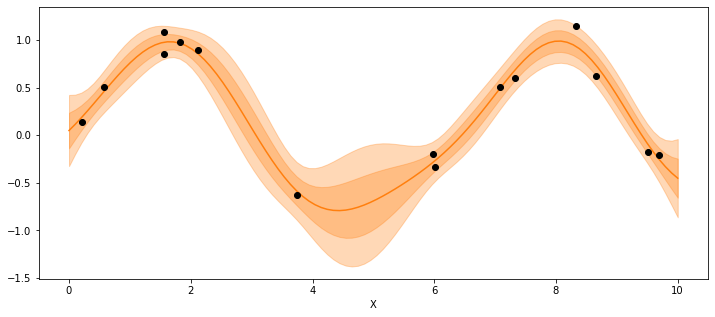

In [305]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

_, ax = plt.subplots(figsize=(12,5))

point = {'length': trace_gp['length'].mean(), 'eps': trace_gp['eps'].mean()}
mu, var = gp.predict(X_new, point=point, diag=True)
sd = var**0.5


ax.plot(X_new, mu, 'C1')
ax.fill_between(X_new.flatten(),
                 mu - sd, mu + sd,
                 color="C1",
                 alpha=0.3)

ax.fill_between(X_new.flatten(),
                 mu - 2*sd, mu + 2*sd,
                 color="C1",
                 alpha=0.3)

ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.show()

/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/pymc3/sampling.py:1689: UserWarning: samples parameter is smaller than nchains times ndraws, some draws and/or chains may not be represented in the returned posterior predictive sample
  warnings.warn(


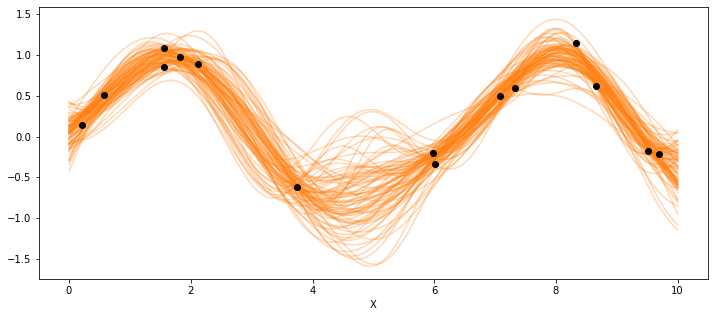

In [311]:
X_new = np.linspace(np.floor(x.min()), np.ceil(x.max()), 100)[:,None]

with model_gp:
    f_pred = gp.conditional('f_pred', X_new)
    pred_samples = pm.sample_posterior_predictive(trace_gp, var_names=["f_pred"], samples=82)

_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, pred_samples['f_pred'].T, 'C1-', alpha=0.3)
ax.plot(X, y, 'ko')
ax.set_xlabel('X')
plt.show()

# Acquisition Function

Obtain a next sample at x=[7.97979798]


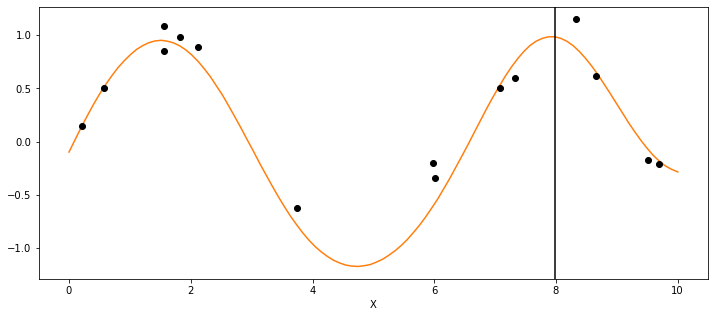

In [343]:
# ... the following code uses a function sampled from the above code's result

f = pred_samples['f_pred'][0].T
_, ax = plt.subplots(figsize=(12,5))
ax.plot(X_new, f, 'C1-')
ax.plot(X, y, 'ko')
ax.set_xlabel('X')


xstar = np.argmax(f)
print(f"Obtain a next sample at x={X_new[xstar]}")

ax.axvline(x=X_new[xstar], color="black")

plt.show()
